In [1]:
########## import some useful package ##########

import time
t1 = time.time()

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import ripser
import persim

In [2]:
########## read the data ##########

processes = [f"run_{i:02d}_decayed_1" for i in range(1,12)]
kappa_3 = [0.2, 0.4, 0.6, 0.8, 0.9, 1, 1.1, 1.2, 1.4, 1.6, 1.8]
Xsection_NoDecay = [1.23322e-01, 1.016366e-01, 8.33476424e-02, 6.81961e-02, 6.2211286e-02, 5.648398e-02, 5.187586e-02, 4.801255e-02, 4.246736e-02, 4.038406e-02, 4.1308219e-02]     ### hhvv unit: fb
# Xsection_NoDecay = [1.068573e-2, 8.89267e-3, 7.29573e-3, 5.892737e-3, 5.2836183e-3, 4.68848e-3, 4.1895e-3, 3.7137245e-3, 2.9218193e-3, 2.3228e-3, 1.9414667e-3]     ### hhmumu unit: fb
BR_hbb = 0.5824
Xsection = []
for i in range(11):
    Xsection.append(Xsection_NoDecay[i]*BR_hbb*BR_hbb)

Luminosity = 1000   ### unit: fb^-1
simulation_num = 100000

features = ["VLCjetR10N2", "VLCjetR10N2.PT", "VLCjetR10N2.Eta", "VLCjetR10N2.Phi", "VLCjetR10N2.Mass", "MissingET.MET", "VLCjetR10N2.BTag", "EFlow.Eta", "EFlow.Phi", "EFlow.ET"]

##### set data path #####

event_path = []
for type in processes:
    event_path.append("/data/mucollider/two_boosted/scan_kappa3_hhvv/Events/" + type + "/delphes_events.root")

##### get the data file #####

data_file =[]
for path in event_path:
    data_file.append(uproot.open(path))
    
##### read data with features #####
events = []     ### total events
for process in processes:
    tmp_events = []
    for feature in features:
        tmp_events.append(data_file[processes.index(process)]["Delphes;1"][feature].array())
    tmp_events = np.expand_dims(tmp_events, axis=-1)
    tmp_events = tmp_events.transpose((1,0,2))
    tmp_events = np.squeeze(tmp_events,axis=(2,))
    events.append(tmp_events)
    print(process, "Time:{:^8.4f}(s)".format(time.time()-t1))
del tmp_events

run_01_decayed_1 Time: 3.8684 (s)
run_02_decayed_1 Time: 6.4825 (s)
run_03_decayed_1 Time: 9.1179 (s)
run_04_decayed_1 Time:11.8099 (s)
run_05_decayed_1 Time:14.2915 (s)
run_06_decayed_1 Time:17.0166 (s)
run_07_decayed_1 Time:19.7894 (s)
run_08_decayed_1 Time:22.2852 (s)
run_09_decayed_1 Time:25.1652 (s)
run_10_decayed_1 Time:27.6575 (s)
run_11_decayed_1 Time:30.1413 (s)


In [3]:
########## define useful function ##########

##### calculate significance #####

def significance(s,b):
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

##### count event number #####

def count(events):
    events_num = []
    for i, process in enumerate(processes):
        events_num.append(len(events[processes.index(process)]))
        print("There are", events_num[i], process, "events. Corresponding cross section:", Xsection[processes.index(process)]*events_num[i]/simulation_num, "(fb)")
        
##### select if Fat Jet >= 2 #####
        
def Fat_Jet_selection(events):
    where1 = np.where(events[:,features.index("VLCjetR10N2")]>=2)
    return events[where1]

##### select if M_jet_leading > XX GeV #####

def mass_leading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][0]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][0]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if M_jet_subleading > XX GeV #####

def mass_subleading_selection(events, low_mass_cut, high_mass_cut):
    where1 = []
    for i in range(len(events)):
        switch=1
        if events[i][features.index("VLCjetR10N2.Mass")][1]<low_mass_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.Mass")][1]>high_mass_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_leading > XX GeV #####

def pT_leading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][0]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][0]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### select if pT_J_subleading > XX GeV #####

def pT_subleading_selection(events, low_pT_cut, high_pT_cut):
    where1 = []
    for i in range(len(events)):
        switch = 1
        if events[i][features.index("VLCjetR10N2.PT")][1]<low_pT_cut:
            switch=0
        if events[i][features.index("VLCjetR10N2.PT")][1]>high_pT_cut:
            switch=0
        if switch==1:
            where1.append(i)
    return events[where1]

##### define X_HH (defined in 2207.09602v2) #####

def calculate_X_HH(event):
    jet_mass1 = event[features.index("VLCjetR10N2.Mass")][0]
    jet_mass2 = event[features.index("VLCjetR10N2.Mass")][1]
    diff1 = np.abs(jet_mass1 - 124)
    diff2 = np.abs(jet_mass2 - 124)
    if diff1<diff2:
        m1 = jet_mass1
        m2 = jet_mass2
    else:
        m1 = jet_mass2
        m2 = jet_mass1
    return np.sqrt(((m1-124)/(0.1*m1+0.00001))**2 + ((m2-115)/(0.1*m2+0.00001))**2)

##### calculate M_JJ #####

def calculate_M_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    M_JJ = np.sqrt(p[0]**2 - p[1]**2 - p[2]**2 - p[3]**2)
    return M_JJ

##### calculate pT_JJ #####

def calculate_pT_JJ(event):
    p = [0,0,0,0]    ### four momentum
    for i in range(2):    ### leading jet and sub-leading jet
        pt = event[features.index("VLCjetR10N2.PT")][i]
        eta = event[features.index("VLCjetR10N2.Eta")][i]
        phi = event[features.index("VLCjetR10N2.Phi")][i]
        mass = event[features.index("VLCjetR10N2.Mass")][i]
        p[1] = p[1] + pt*np.cos(phi)    ### px
        p[2] = p[2] + pt*np.sin(phi)    ### py
        p[3] = p[3] + pt*np.sinh(eta)    ### pz
        p[0] = p[0] + np.sqrt( mass**2 + (pt*np.cos(phi))**2 + (pt*np.sin(phi))**2 + (pt*np.sinh(eta))**2 )    ### energy
    pT_JJ = np.sqrt(p[1]**2 + p[2]**2)
    return pT_JJ

##### calculate \Delta_\Eta #####

def calculate_dEta_JJ(event):
    return np.abs(event[features.index("VLCjetR10N2.Eta")][0] - event[features.index("VLCjetR10N2.Eta")][1])

##### select if 2 Jets pass BTag WP70 #####

def two_BTag_selection(event):
    where1 = []
    for i in range(len(event)):
        BTag_leading = event[i][features.index("VLCjetR10N2.BTag")][0]
        BTag_subleading = event[i][features.index("VLCjetR10N2.BTag")][1]
        if (((BTag_leading&2)==2) and ((BTag_subleading&2)==2)):
            where1.append(i)
    return event[where1]

In [4]:
########## preselection ##########

print("Before any selection:")
count(events)

##### 2 fat jet selection #####

for process in processes:
    events[processes.index(process)] = Fat_Jet_selection(events[processes.index(process)])
print("\nAfter 2 fat jet selection:")
count(events)

Before any selection:
There are 100000 run_01_decayed_1 events. Corresponding cross section: 0.041829559582720006 (fb)
There are 100000 run_02_decayed_1 events. Corresponding cross section: 0.034474093961216 (fb)
There are 100000 run_03_decayed_1 events. Corresponding cross section: 0.02827066682222183 (fb)
There are 100000 run_04_decayed_1 events. Corresponding cross section: 0.023131418791935997 (fb)
There are 100000 run_05_decayed_1 events. Corresponding cross section: 0.021101431167631364 (fb)
There are 100000 run_06_decayed_1 events. Corresponding cross section: 0.019158787620044804 (fb)
There are 100000 run_07_decayed_1 events. Corresponding cross section: 0.017595760503193603 (fb)
There are 100000 run_08_decayed_1 events. Corresponding cross section: 0.016285365311488 (fb)
There are 100000 run_09_decayed_1 events. Corresponding cross section: 0.014404493646233602 (fb)
There are 100000 run_10_decayed_1 events. Corresponding cross section: 0.013697859619225601 (fb)
There are 10000

In [5]:
########## visualization of kinematics ##########

m_J_leading = []
m_J_subleading = []
pt_J_leading = []
pt_J_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_m1 = []
    tmp_m2 = []
    tmp_pt1 = []
    tmp_pt2 = []
    for i in range(len(events[processes.index(process)])):
        tmp_m1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][0])
        tmp_m2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.Mass")][1])
        tmp_pt1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][0])
        tmp_pt2.append(events[processes.index(process)][i][features.index("VLCjetR10N2.PT")][1])
    m_J_leading.append(tmp_m1)
    m_J_subleading.append(tmp_m2)
    pt_J_leading.append(tmp_pt1)
    pt_J_subleading.append(tmp_pt2)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
del tmp_m1, tmp_m2, tmp_pt1, tmp_pt2

Time:30.6696 (s)
Time:30.8865 (s)
Time:31.1127 (s)
Time:31.3327 (s)
Time:31.5604 (s)
Time:31.7945 (s)
Time:32.0368 (s)
Time:32.2764 (s)
Time:32.5221 (s)
Time:32.7696 (s)
Time:33.0272 (s)


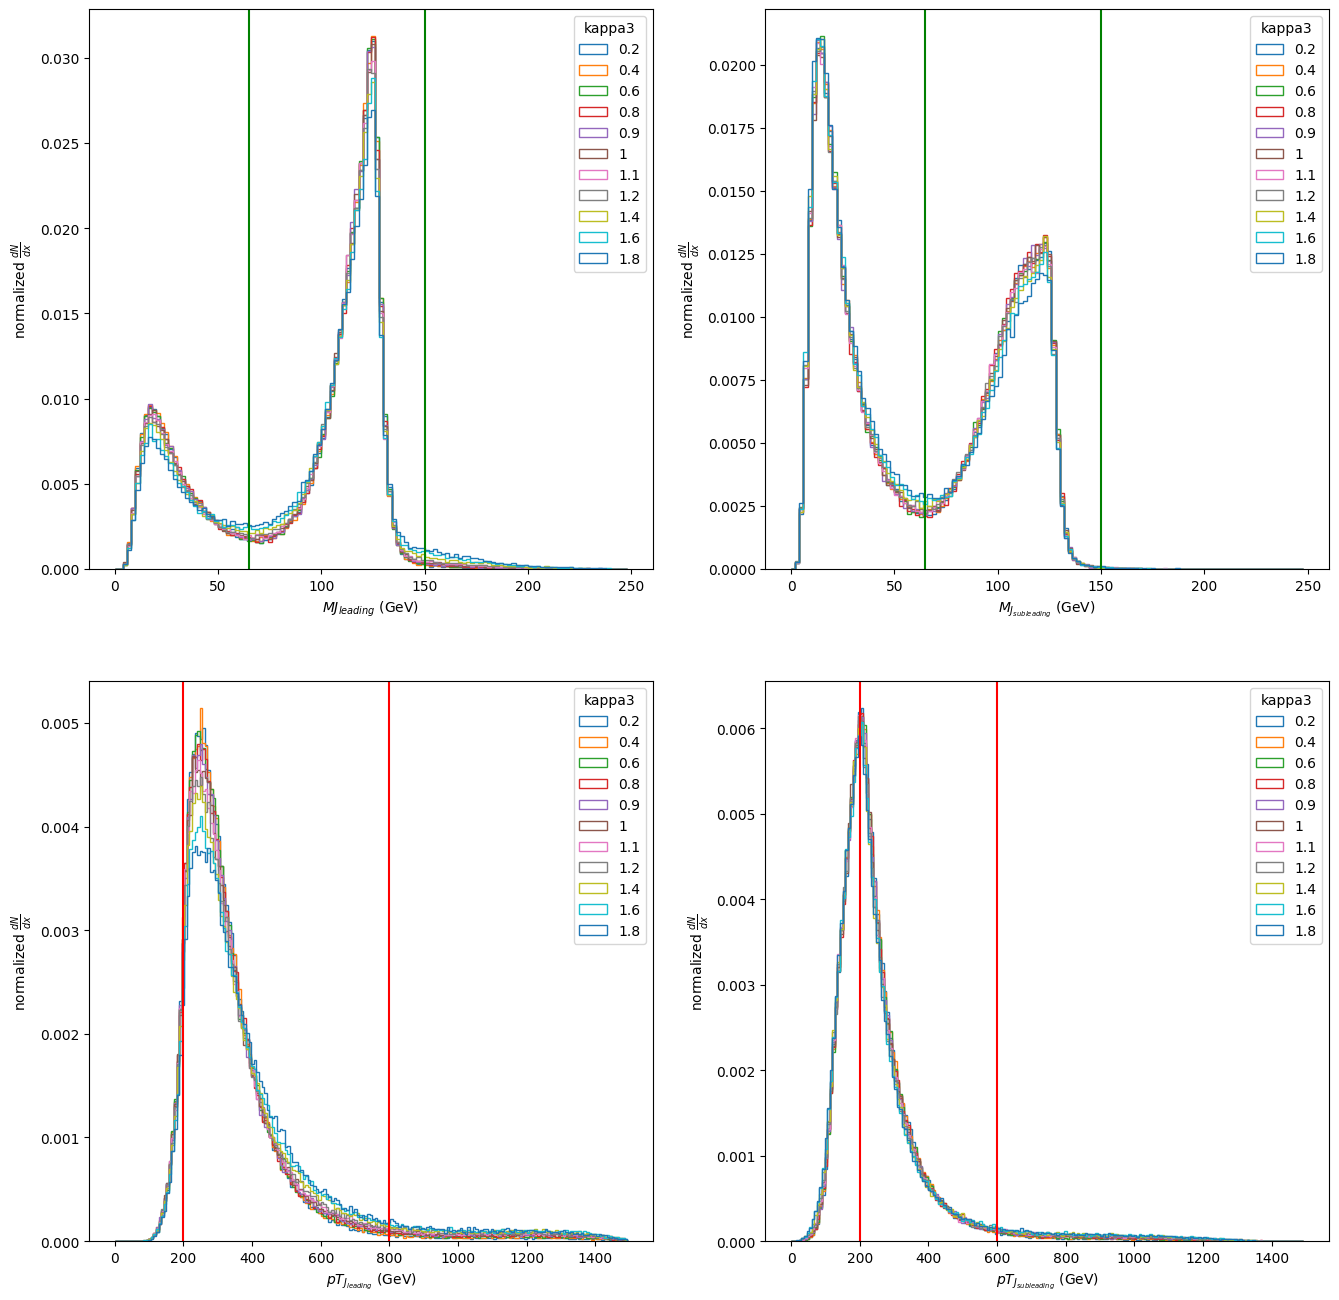

In [6]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 16))

fig.add_subplot(221)     ### plot leading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_leading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(222)     ### plot subleading jet mass
bins = np.arange(0,250,2)
for process in processes:
    plt.hist(m_J_subleading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(65, color='g')
plt.axvline(150, color='g')
plt.xlabel(r"$M_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(223)     ### plot leading jet PT
bins = np.arange(0,1500,7.5)
for process in processes:
    plt.hist(pt_J_leading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(800, color='r')
plt.xlabel(r"$pT_{J_{leading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(224)     ### plot subleading jet PT
bins = np.arange(0,1500,7.5)
for process in processes:
    plt.hist(pt_J_subleading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.axvline(200, color='r')
plt.axvline(600, color='r')
plt.xlabel(r"$pT_{J_{subleading}} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

plt.show()

In [7]:
########## Do some basic cuts ##########

##### leading jet pT selection #####

leading_low_pT_cut = 200   ### GeV
leading_high_pT_cut = 800   ### GeV
for process in processes:
    events[processes.index(process)] = pT_leading_selection(events[processes.index(process)], leading_low_pT_cut, leading_high_pT_cut)
print("\nAfter leading jet pT selection:")
count(events)

##### subleading jet pT selection #####

subleading_low_pT_cut = 200   ### GeV
subleading_high_pT_cut = 600   ### GeV
for process in processes:
    events[processes.index(process)] = pT_subleading_selection(events[processes.index(process)], subleading_low_pT_cut, subleading_high_pT_cut)
print("\nAfter subleading jet pT selection:")
count(events)

##### leading jet mass selection #####

leading_low_mass_cut = 65
leading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_leading_selection(events[processes.index(process)], leading_low_mass_cut, leading_high_mass_cut)
print("\nAfter leading jet mass selection:")
count(events)

##### subleading jet mass selection #####

subleading_low_mass_cut = 65
subleading_high_mass_cut = 150
for process in processes:
    events[processes.index(process)] = mass_subleading_selection(events[processes.index(process)], subleading_low_mass_cut, subleading_high_mass_cut)
print("\nAfter subleading jet mass selection:")
count(events)


After leading jet pT selection:
There are 89914 run_01_decayed_1 events. Corresponding cross section: 0.03761063020320687 (fb)
There are 89420 run_02_decayed_1 events. Corresponding cross section: 0.030826734820119345 (fb)
There are 88944 run_03_decayed_1 events. Corresponding cross section: 0.025145061898356986 (fb)
There are 88416 run_04_decayed_1 events. Corresponding cross section: 0.020451875239078134 (fb)
There are 87920 run_05_decayed_1 events. Corresponding cross section: 0.018552378282581494 (fb)
There are 87545 run_06_decayed_1 events. Corresponding cross section: 0.016772560621968222 (fb)
There are 87165 run_07_decayed_1 events. Corresponding cross section: 0.015337344642608705 (fb)
There are 86813 run_08_decayed_1 events. Corresponding cross section: 0.01413781418786208 (fb)
There are 86482 run_09_decayed_1 events. Corresponding cross section: 0.012457294195135743 (fb)
There are 86431 run_10_decayed_1 events. Corresponding cross section: 0.01183919704749288 (fb)
There are 

In [8]:
########## visualization of other kinematics ##########

missET = []
X_HH = []
M_JJ = []
pT_JJ = []
dEta_JJ = []
BTag_leading = []
BTag_subleading = []

##### calculate kinematics #####

for process in processes:
    tmp_met = []
    tmp_X_HH = []
    tmp_M_JJ = []
    tmp_pT_JJ = []
    tmp_dEta_JJ = []
    tmp_Btag_0 = []
    tmp_Btag_1 = []
    for i in range(len(events[processes.index(process)])):
        tmp_met.append(events[processes.index(process)][i][features.index("MissingET.MET")][0])
        tmp_X_HH.append(calculate_X_HH(events[processes.index(process)][i]))
        tmp_M_JJ.append(calculate_M_JJ(events[processes.index(process)][i]))
        tmp_pT_JJ.append(calculate_pT_JJ(events[processes.index(process)][i]))
        tmp_dEta_JJ.append(calculate_dEta_JJ(events[processes.index(process)][i]))
        tmp_Btag_0.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][0])
        tmp_Btag_1.append(events[processes.index(process)][i][features.index("VLCjetR10N2.BTag")][1])
    missET.append(tmp_met)
    X_HH.append(tmp_X_HH)
    M_JJ.append(tmp_M_JJ)
    pT_JJ.append(tmp_pT_JJ)
    dEta_JJ.append(tmp_dEta_JJ)
    BTag_leading.append(tmp_Btag_0)
    BTag_subleading.append(tmp_Btag_1)
    print("Time:{:^8.4f}(s)".format(time.time()-t1))
    
del tmp_met, tmp_X_HH, tmp_M_JJ, tmp_pT_JJ, tmp_dEta_JJ, tmp_Btag_0, tmp_Btag_1

Time:65.1427 (s)
Time:68.4630 (s)
Time:71.7510 (s)
Time:75.0145 (s)
Time:78.2529 (s)
Time:81.4269 (s)
Time:84.5386 (s)
Time:87.6264 (s)
Time:90.5828 (s)
Time:93.4511 (s)
Time:96.2245 (s)


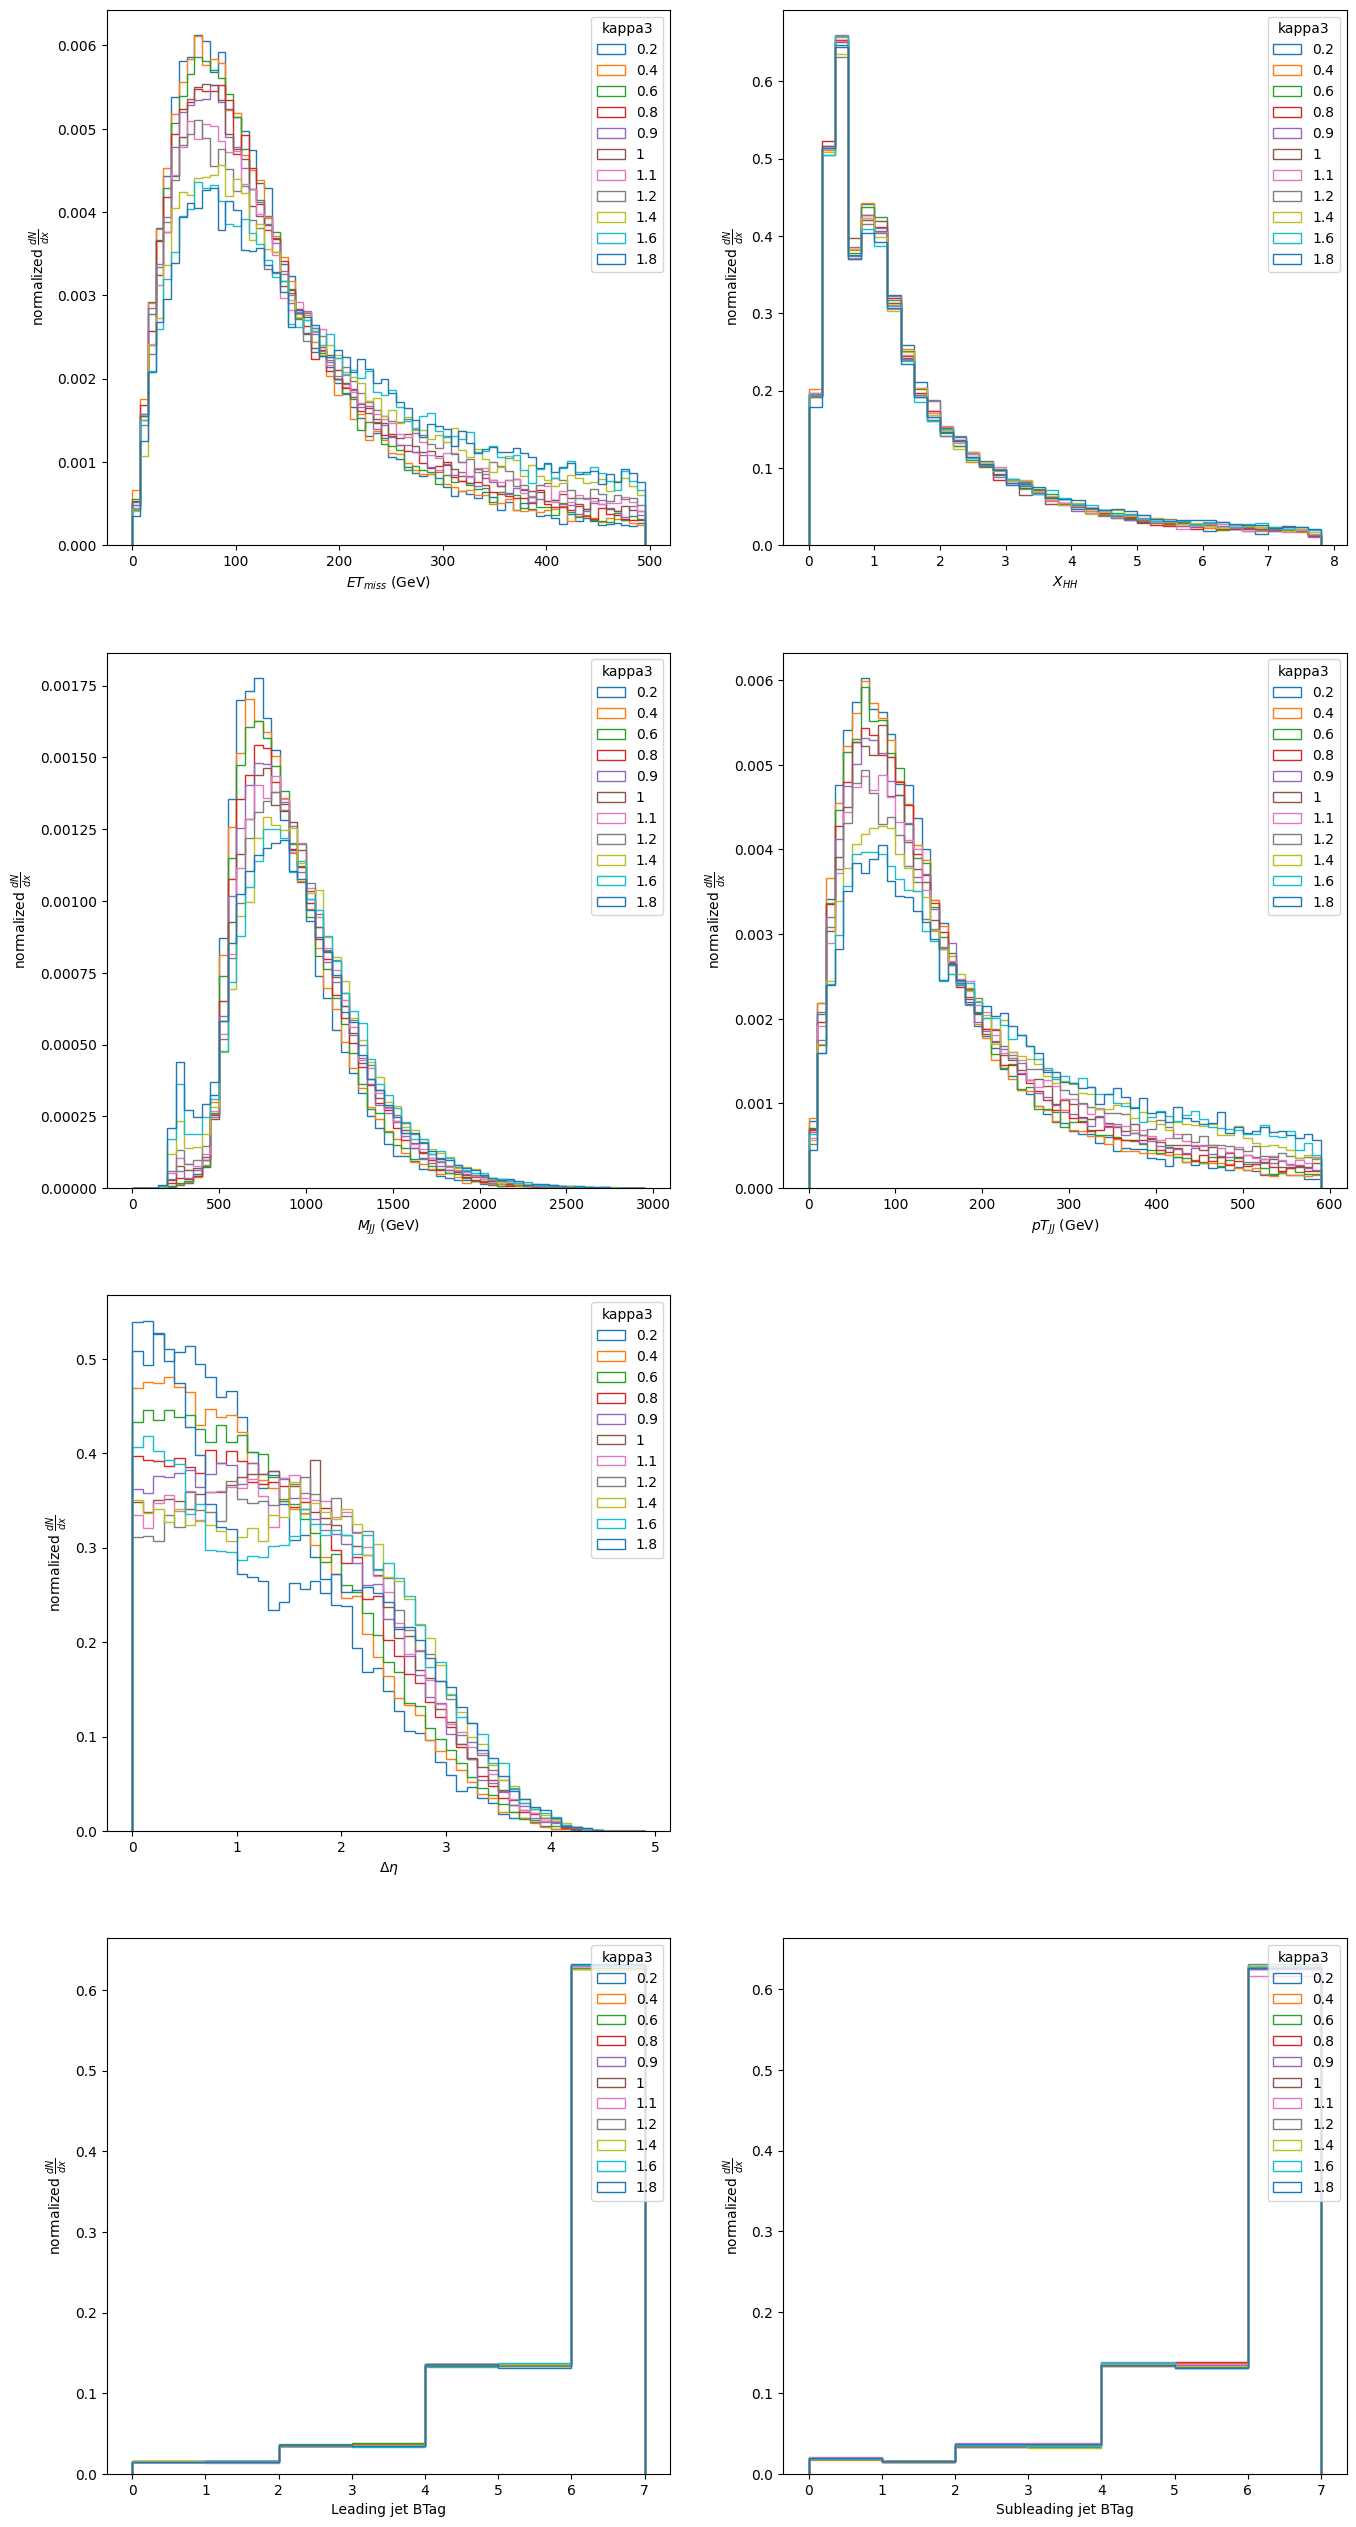

In [13]:
##### plot the histogram #####

fig = plt.figure(figsize=(16, 32))

fig.add_subplot(421)     ### plot MET
bins = np.arange(0,500,7.5)
for process in processes:
    plt.hist(missET[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$ET_{miss} ~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(422)     ### plot X_HH
bins = np.arange(0,8,0.2)
for process in processes:
    plt.hist(X_HH[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$X_{HH}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(423)     ### plot M_JJ
bins = np.arange(0,3000,50)
for process in processes:
    plt.hist(M_JJ[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$M_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(424)     ### plot pT_JJ
bins = np.arange(0,600,10)
for process in processes:
    plt.hist(pT_JJ[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$pT_{JJ}~\rm{(GeV)}$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(425)     ### plot dEta_JJ
bins = np.arange(0,5,0.1)
for process in processes:
    plt.hist(dEta_JJ[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"$\Delta \eta$", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(427)     ### plot BTag of leading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_leading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Leading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

fig.add_subplot(428)     ### plot BTag of subleading jet
bins = np.arange(0,8,1)
for process in processes:
    plt.hist(BTag_subleading[processes.index(process)], bins=bins, label=kappa_3[processes.index(process)], histtype=('stepfilled' if (process=='hhvv' or process=='hhmumu') else 'step'), density=True, alpha=(0.5 if (process=='hhvv' or process=='hhmumu') else 1))
plt.xlabel(r"Subleading jet BTag", fontsize=10)
plt.ylabel(r"normalized $\frac{dN}{dx}$", fontsize=10)
plt.legend(loc='best', title='kappa3')

plt.show()

In [10]:
##### two BTag selection #####

for process in processes:
    events[processes.index(process)] = two_BTag_selection(events[processes.index(process)])
print("After 2 BTag selection:")
count(events)

After 2 BTag selection:
There are 15440 run_01_decayed_1 events. Corresponding cross section: 0.006458483999571969 (fb)
There are 15122 run_02_decayed_1 events. Corresponding cross section: 0.005213172488815083 (fb)
There are 15120 run_03_decayed_1 events. Corresponding cross section: 0.004274524823519941 (fb)
There are 14804 run_04_decayed_1 events. Corresponding cross section: 0.0034243752379582056 (fb)
There are 14608 run_05_decayed_1 events. Corresponding cross section: 0.0030824970649675895 (fb)
There are 14490 run_06_decayed_1 events. Corresponding cross section: 0.002776108326144492 (fb)
There are 14135 run_07_decayed_1 events. Corresponding cross section: 0.002487160747126416 (fb)
There are 13895 run_08_decayed_1 events. Corresponding cross section: 0.002262851510031258 (fb)
There are 13355 run_09_decayed_1 events. Corresponding cross section: 0.0019237201264544976 (fb)
There are 12946 run_10_decayed_1 events. Corresponding cross section: 0.0017733249063049462 (fb)
There are 12

In [11]:
# data_file[processes=="hhvv"]["Delphes;1"].show()

##### show the event #####

events[0][4]

array([2, array([408.37335, 400.9387 ], dtype=float32),
       array([1.7698857 , 0.33506715], dtype=float32),
       array([ 2.098874 , -1.0128691], dtype=float32),
       array([129.87456 , 126.090355], dtype=float32),
       array([12.214625], dtype=float32), array([7, 7], dtype=uint32),
       array([-0.12509085, -0.07660335,  0.04672424,  0.0593558 ,  0.11241505,
               0.11825582,  0.1579703 ,  0.14872888,  0.22870123,  0.2554992 ,
               0.25003552,  0.24928913,  0.288365  ,  0.2991202 ,  0.31551933,
               0.30533797,  0.30472273,  0.33138046,  0.32233787,  0.3316601 ,
               0.33663258,  0.34538975,  0.34340778,  0.34691542,  0.34861988,
               0.36055818,  0.36294913,  0.370381  ,  0.3641447 ,  0.38864422,
               0.3851017 ,  0.3932576 ,  0.39594647,  0.41445705,  0.39984885,
               0.46259418,  0.4618776 ,  0.45007122,  0.49016985,  0.567552  ,
               1.1122018 ,  1.105913  ,  1.1887845 ,  1.3953434 ,  1.4666615

In [12]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:106.1970(s)
